Code to run the emcee method to estimate the posterior distributions of parameters given data in a SEIR model 

In [1]:
%reset -f
import numpy as np
from samplers.SEIR_emcee import SEIR_emcee
from samplers.SEIR_pytwalk import SEIR_pytwalk
from samplers.SEIR_pyhmc import SEIR_pyhmc
from epidemic_model import SEIR_Model
from utils.utils import load_data, parser
import sys
import matplotlib.pyplot as plt
from time import time
from joblib import dump, load

In [2]:
from bokeh.io import output_notebook, show

output_notebook()

Loading BokehJS ...

Data loaded from file:  data/Smoothed_Cases_Third_Wave.csv


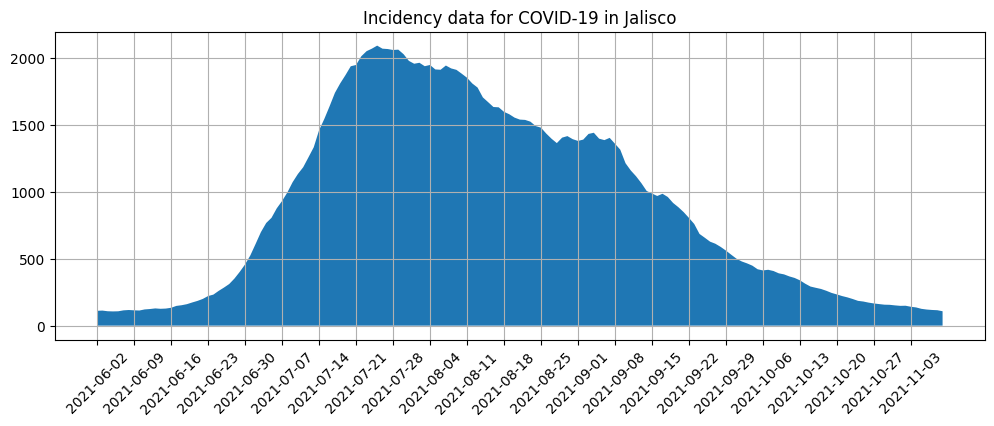

In [3]:
# Loading configuration from configuration file
fname_conf = './configuration_file_test.cfg'

params = parser(fname_conf)

times, data, dates = load_data(params['fname'])

print('Data loaded from file: ', params['fname'])

# plotting data
plt.figure(figsize=(12,4))
plt.fill_between(dates,data, label='Incidency data')
plt.xticks(dates[::7],rotation=45)
plt.title('Incidency data for COVID-19 in Jalisco')
plt.grid()
plt.show()


In [ ]:
# Total population size is taken from the configuration file
N = params["N"]

#sigma_0 = 1/params["incubation_period"]
#gamma_0 = 1/params["infectious_period"]

# Setting initial conditions
I0 = params['I0']
E0 = data[0]/sigma_0 + gamma_0/sigma_0*I0
R0 = 0
S0 = N - E0 - I0 - R0

x0 = [S0,E0,I0,R0]

iterations = params['iterations']  # Number of iterations for the MCMC sampler
ndim = 3                           # Dimension of the problem is 3: beta, sigma, gamma
nwalkers = 3*ndim                  # Number of walkers for the MCMC sampler

reload_flag = (params['reload'] == 1)
out_file = params['outfile']
outpath = params['outpath']

In [5]:

#### Run this cell in case that are loading a previous run
if reload_flag :
    seir_emcee = load(outpath+'/emcee/'+out_file)
    seir_emcee.outpath = outpath

In [6]:
if not reload_flag :
    # Building the emcee MCMC sampler
    seir_emcee = SEIR_emcee(
        ndim = ndim,
        nwalkers = nwalkers,
        data=data,
        time=times,
        labels=['beta', 'sigma', 'gamma'],
        x0=x0,
        **params
        )

    p0 = np.array([0.25,0.5,0.1])                               # Initial guess for the parameters
    theta_0 = p0+np.random.randn(nwalkers, ndim) * 1e-2         # initial guess for the walkers. Are build around the initial guess


Incidency will be computed using method:  roman


In [7]:
if not reload_flag :
    # Running the MCMC sampler
    ini_time = time()
    seir_emcee.run(iterations, theta_0)
    end_time = time()
    print('Time elapsed: ', end_time-ini_time)

    dump(seir_emcee, outpath+'/emcee/'+out_file)


100%|██████████| 10000/10000 [27:53<00:00,  5.98it/s]


Time elapsed:  1673.6418204307556


In [8]:
seir_emcee.summary()

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.340  0.023   0.339    0.348      0.001    0.004      14.0      64.0   
sigma  0.053  0.041   0.048    0.049      0.001    0.008      13.0      38.0   
gamma  0.042  0.002   0.041    0.043      0.000    0.000      15.0      34.0   

       r_hat  
beta    1.71  
sigma   1.91  
gamma   1.63  


<Figure size 640x480 with 0 Axes>

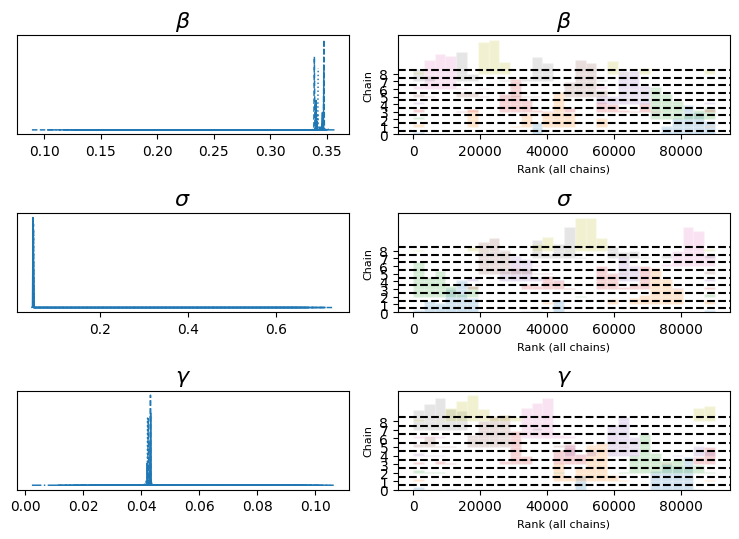

In [9]:
seir_emcee.plot_rank_bars()

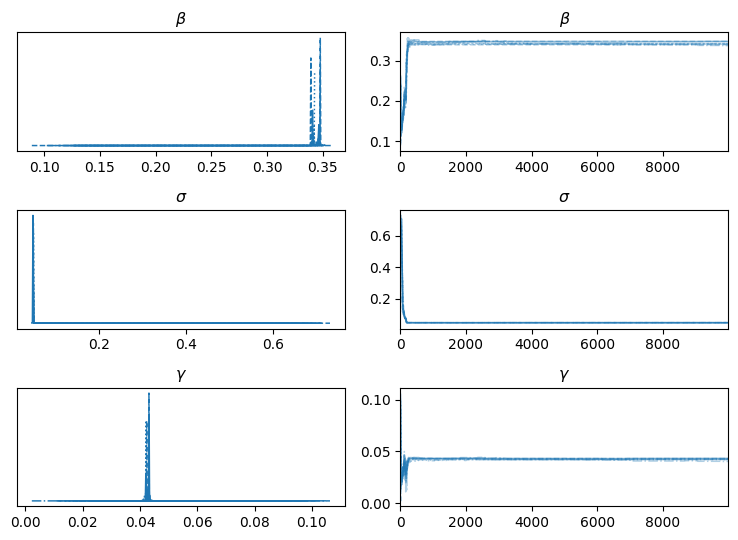

In [10]:
seir_emcee.plot_trace()

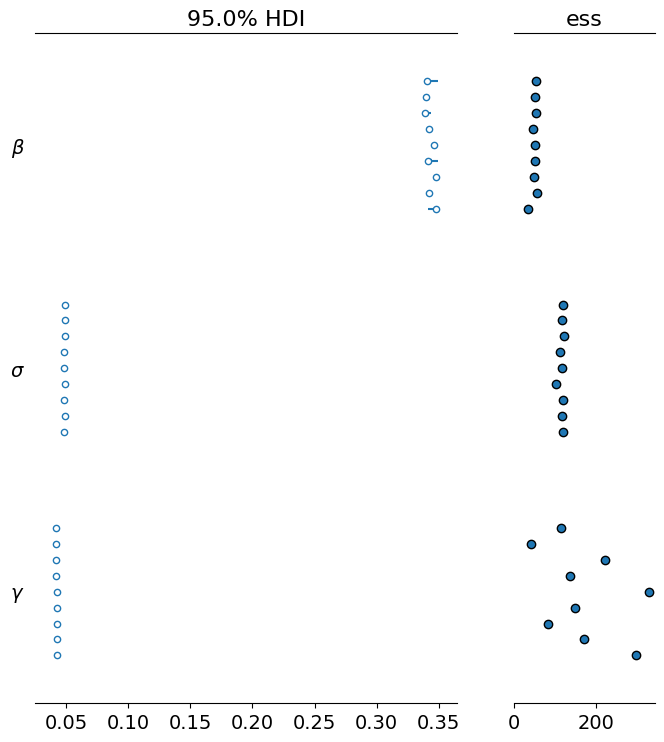

In [11]:
seir_emcee.plot_forest()

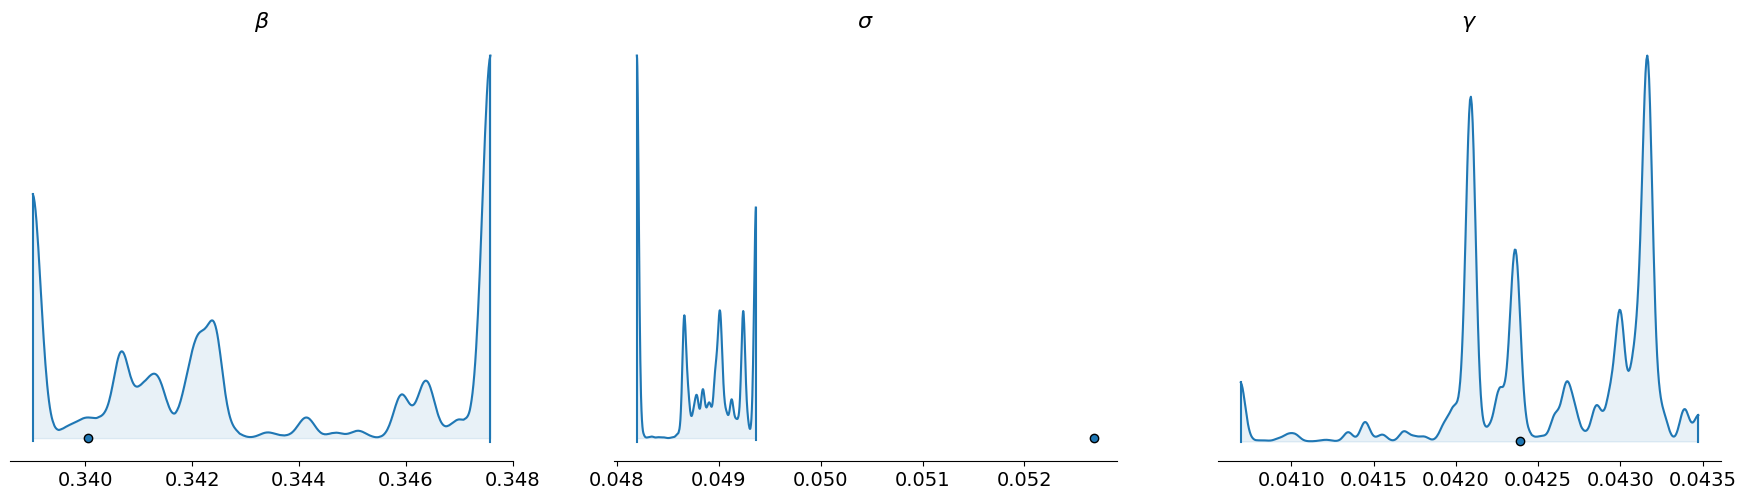

In [12]:
seir_emcee.plot_density()

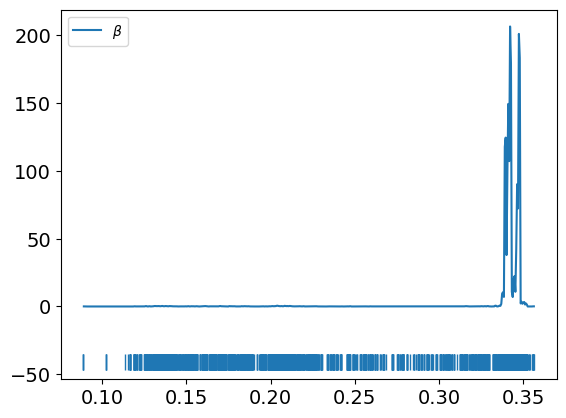

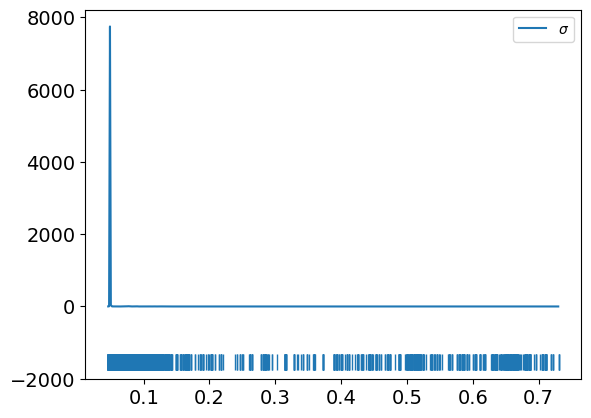

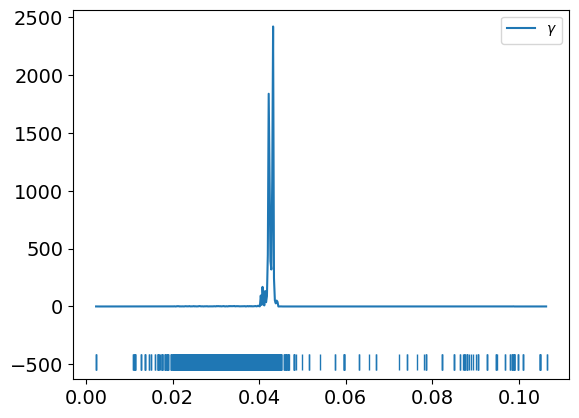

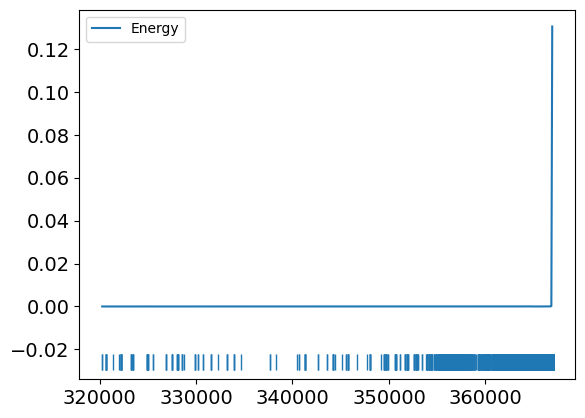

In [13]:
seir_emcee.plot_histograms()


ValueError: Contour levels must be increasing

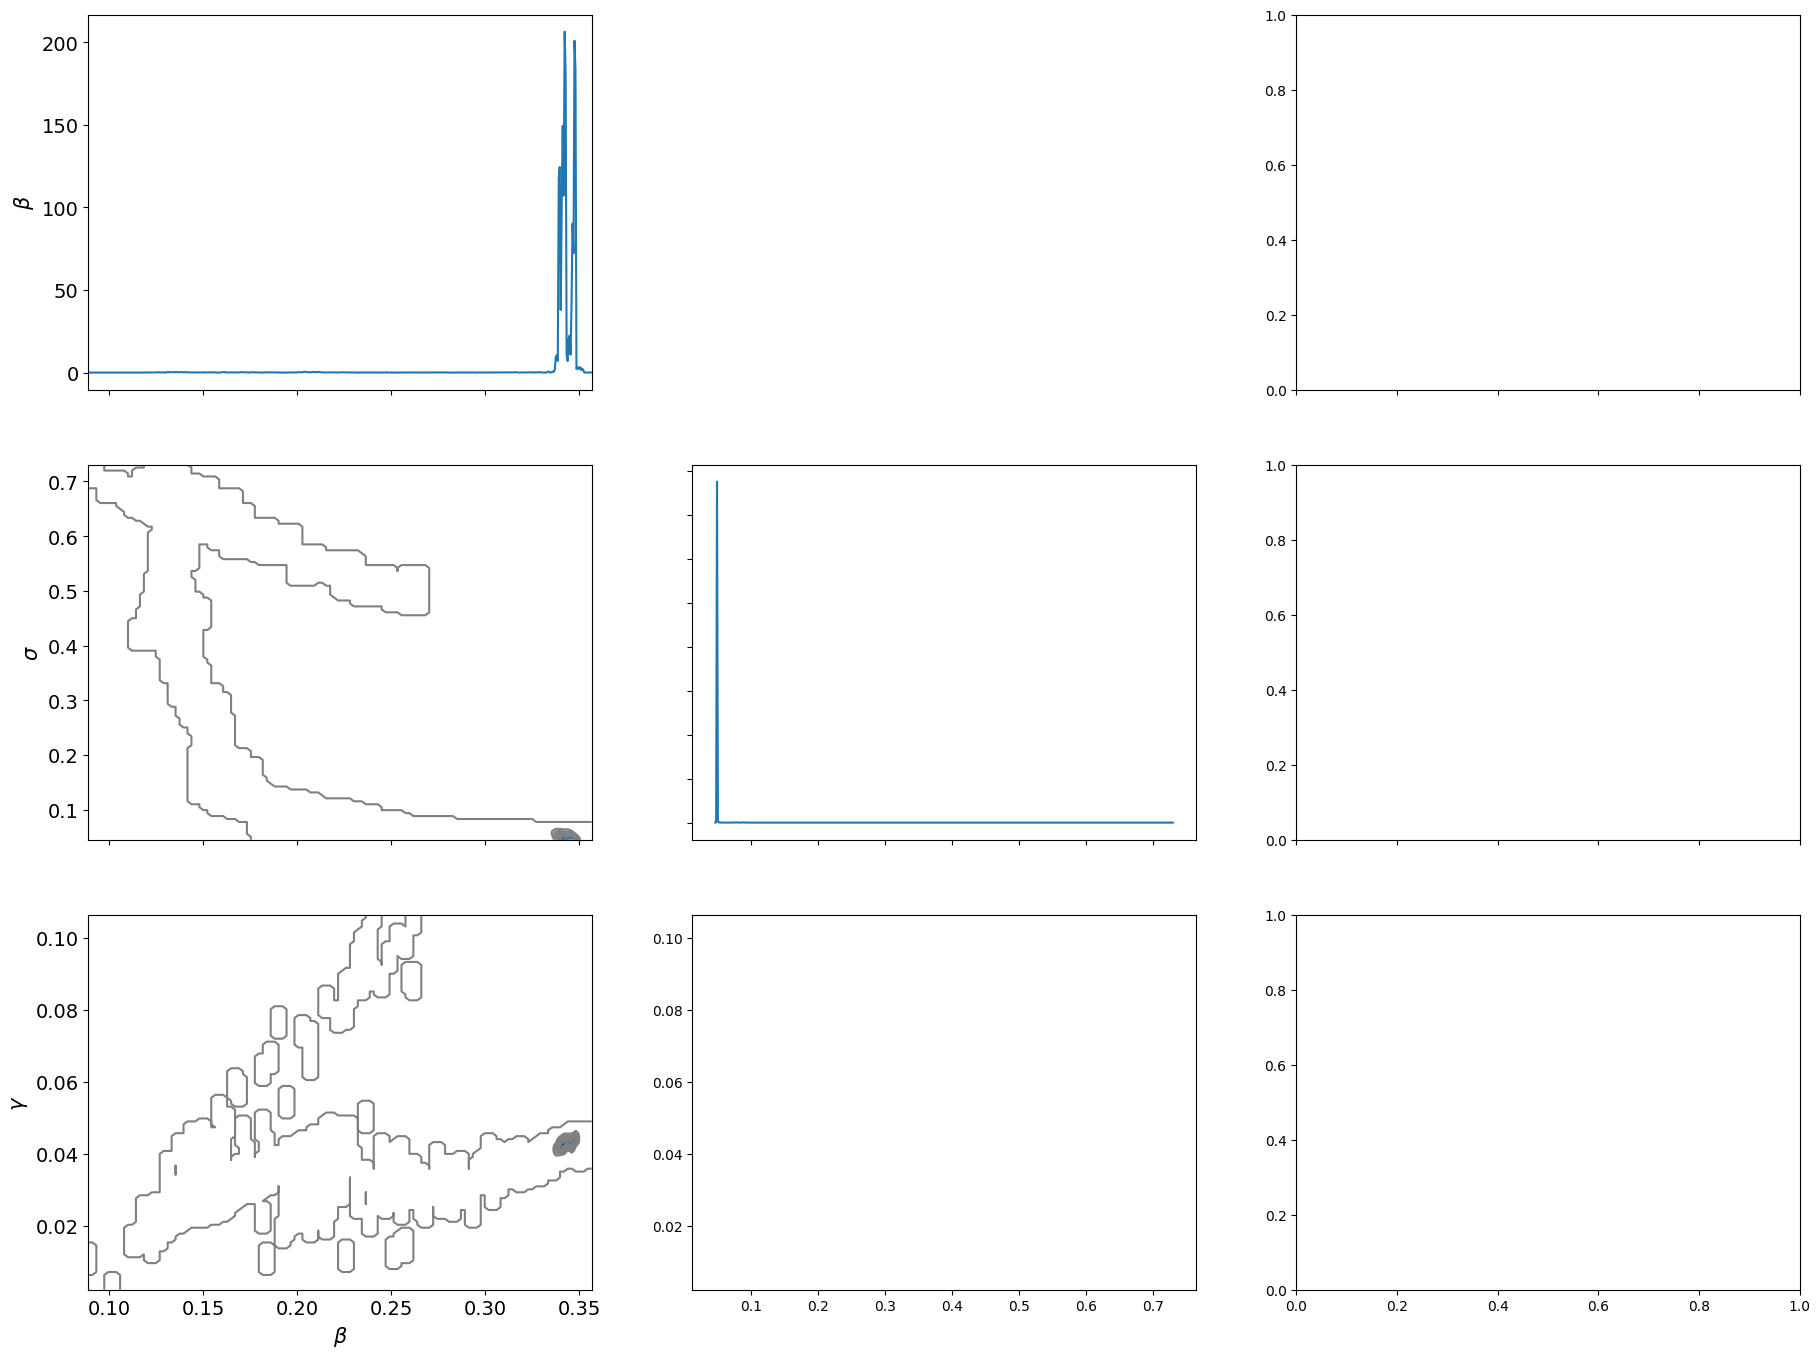

In [14]:
seir_emcee.plot_pair()

In [ ]:
seir_emcee.plot_posterior()

In [ ]:
seir_emcee.plot_parallel()


In [ ]:
seir_emcee.plot_autocorr()

In [ ]:
seir_emcee.plot_energy()

In [ ]:
seir_emcee.plot_dist_comparison()


In [ ]:
seir_emcee.plot_ppc(10)

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.343  0.003   0.339    0.348      0.001      0.0      11.0      24.0   
sigma  0.049  0.000   0.048    0.049      0.000      0.0      10.0      15.0   
gamma  0.043  0.001   0.041    0.043      0.000      0.0      12.0      16.0   

       r_hat  
beta    2.38  
sigma   2.99  
gamma   2.10  


<Figure size 640x480 with 0 Axes>

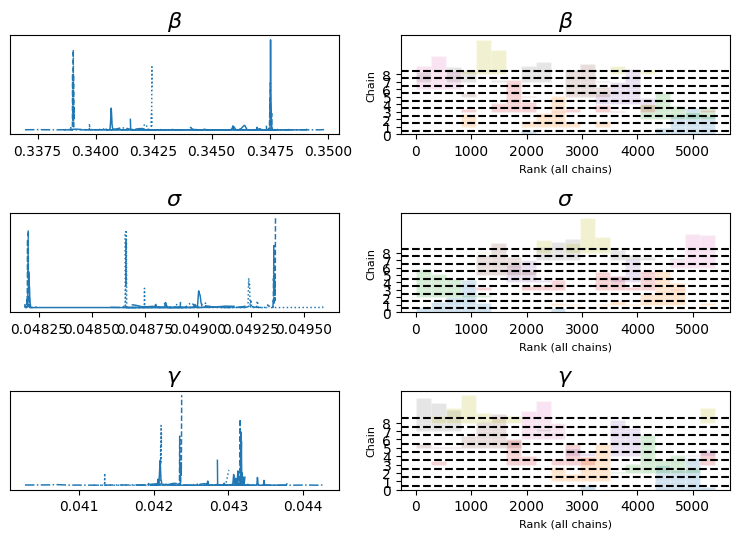

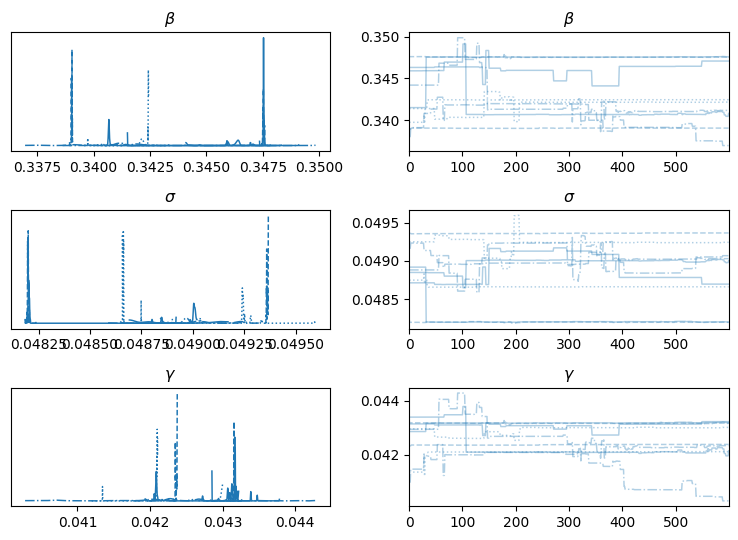

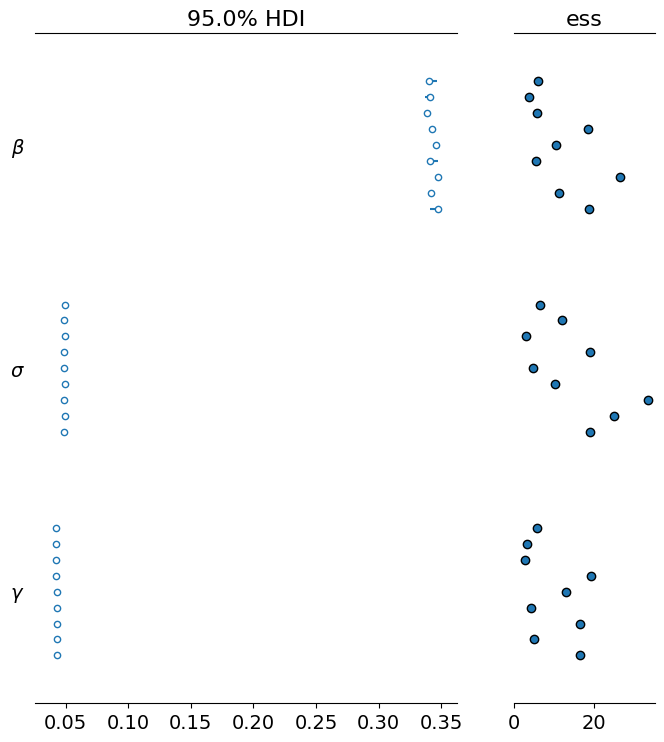

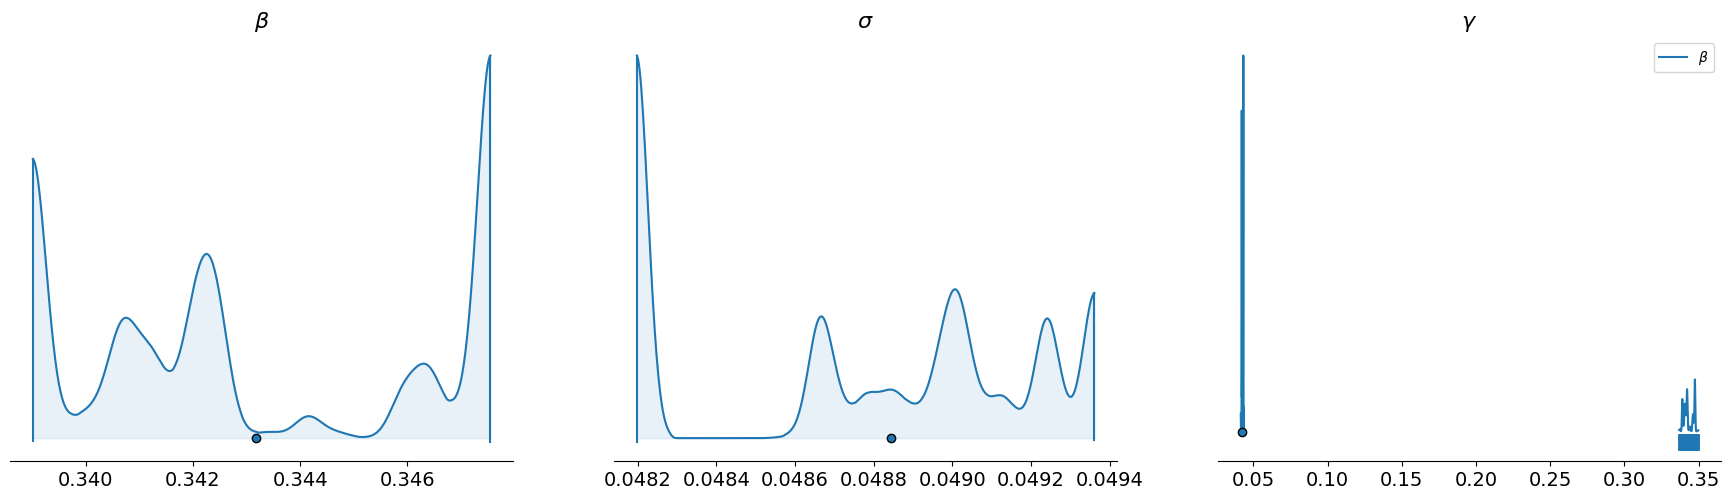

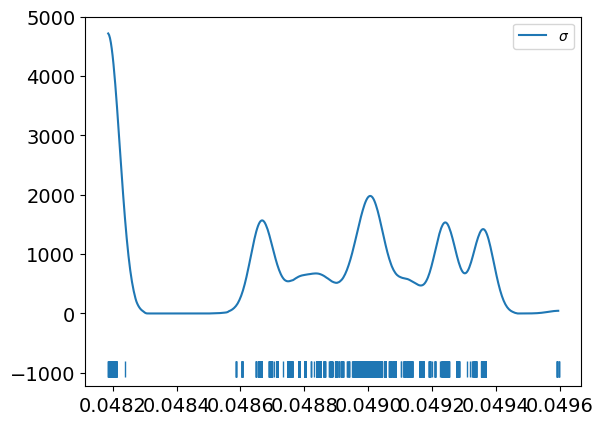

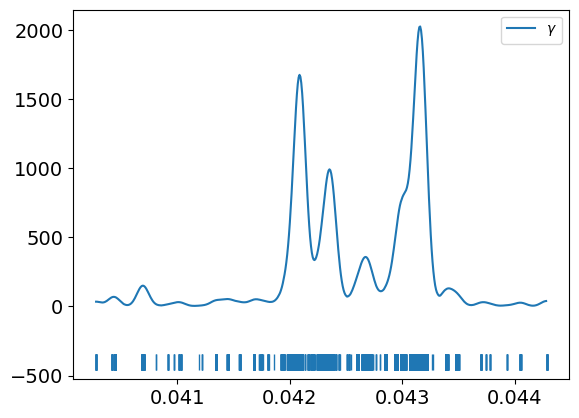

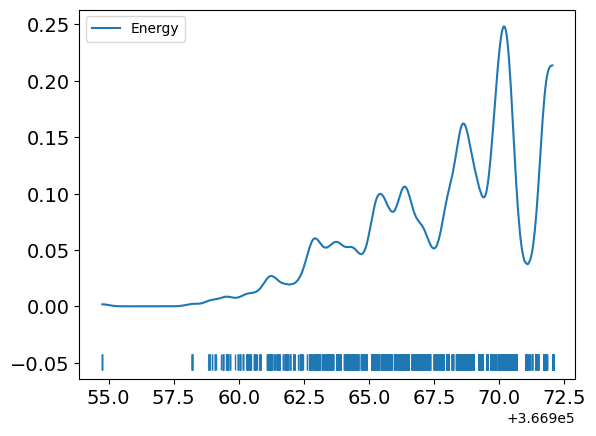

Generating 10 prior samples. Prior model: Gamma
Generating prior curves. Prior model: Gamma


/home/abel/seir_uq_methods/utils/AnalysisTools.py:293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:293: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:294: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/hom

Using 300 samples


100%|██████████| 2700/2700 [00:49<00:00, 54.76it/s]


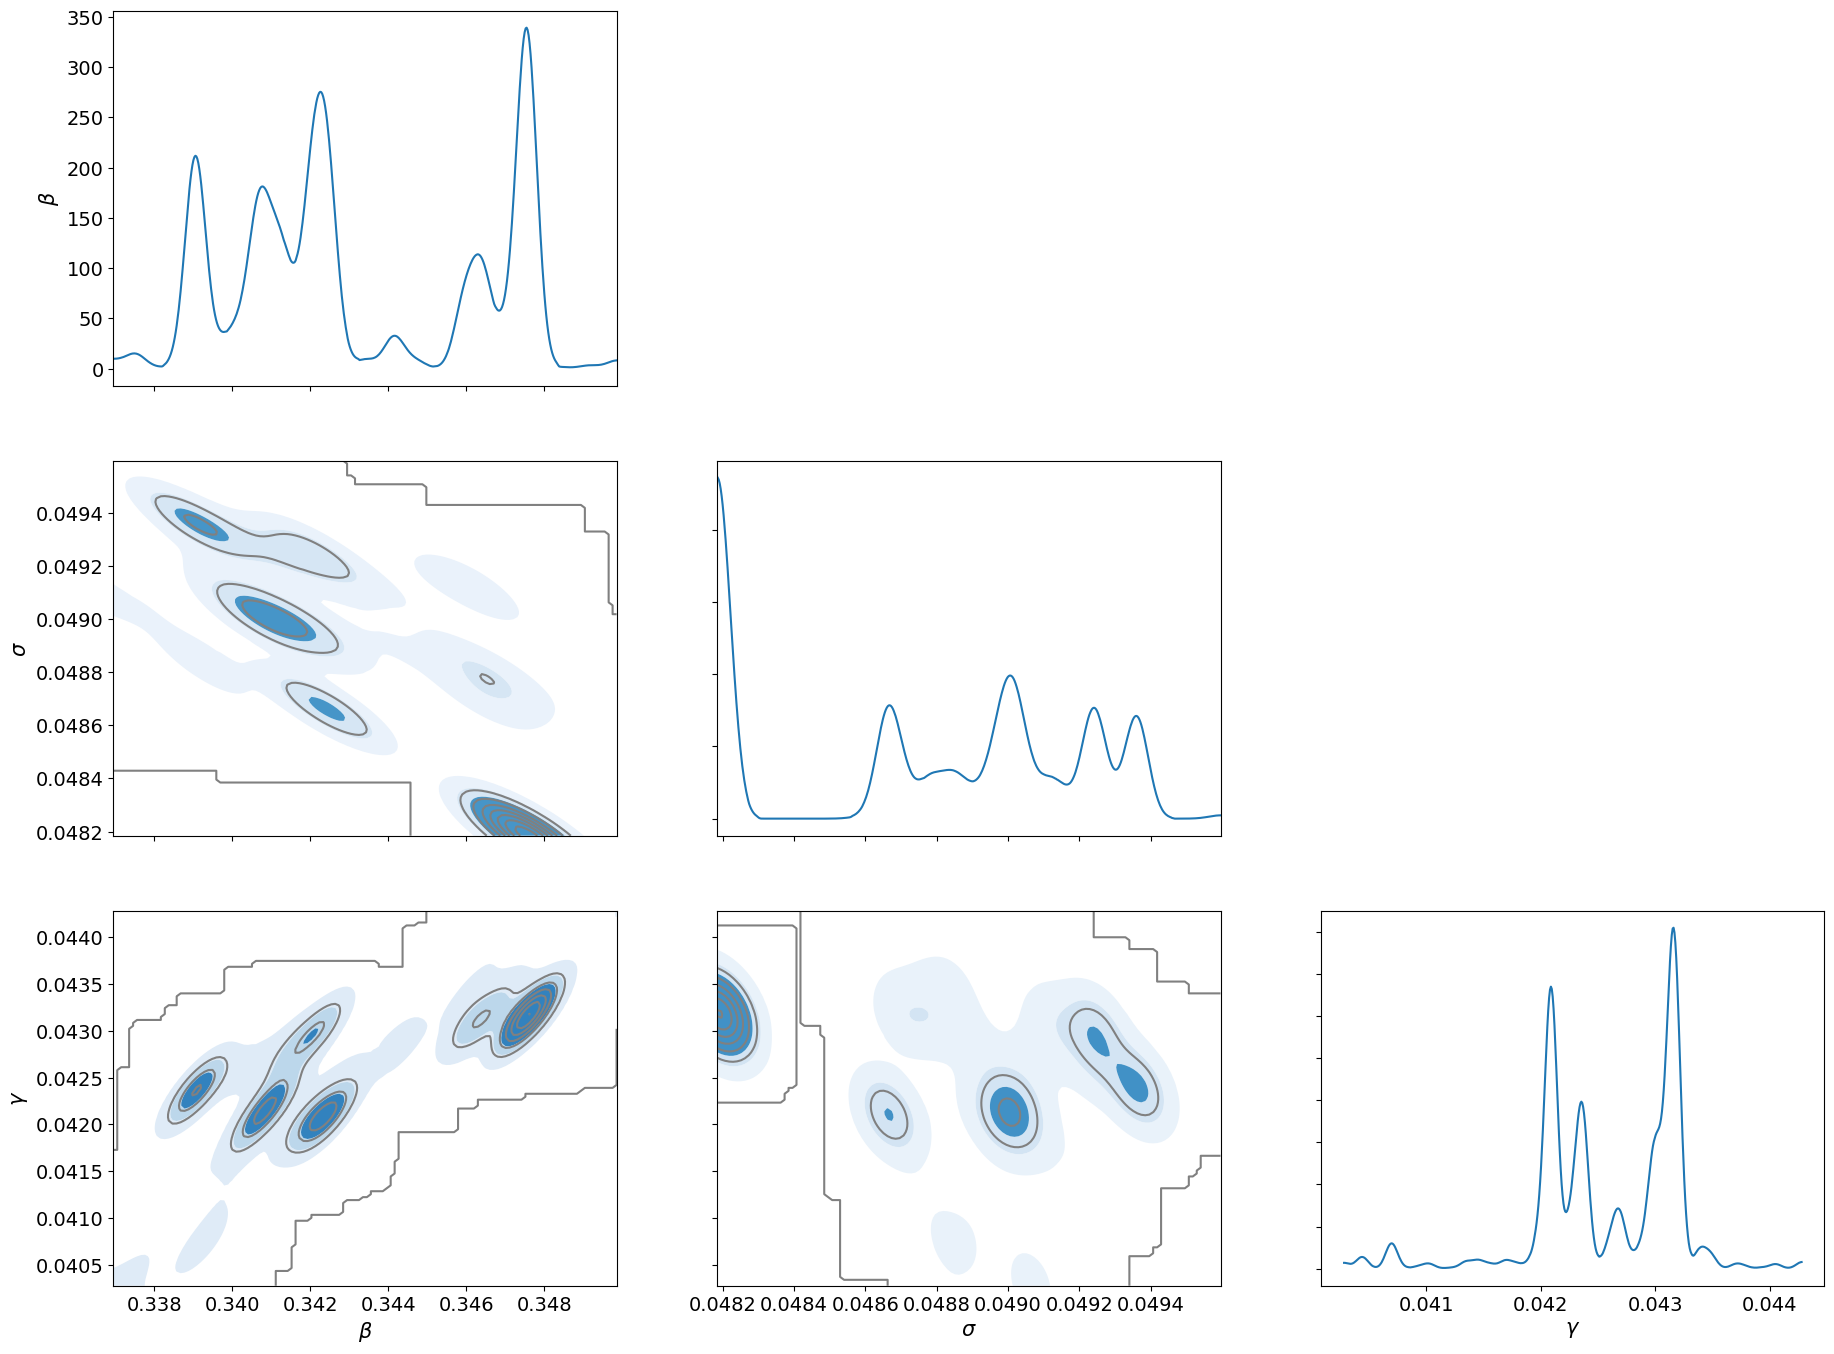

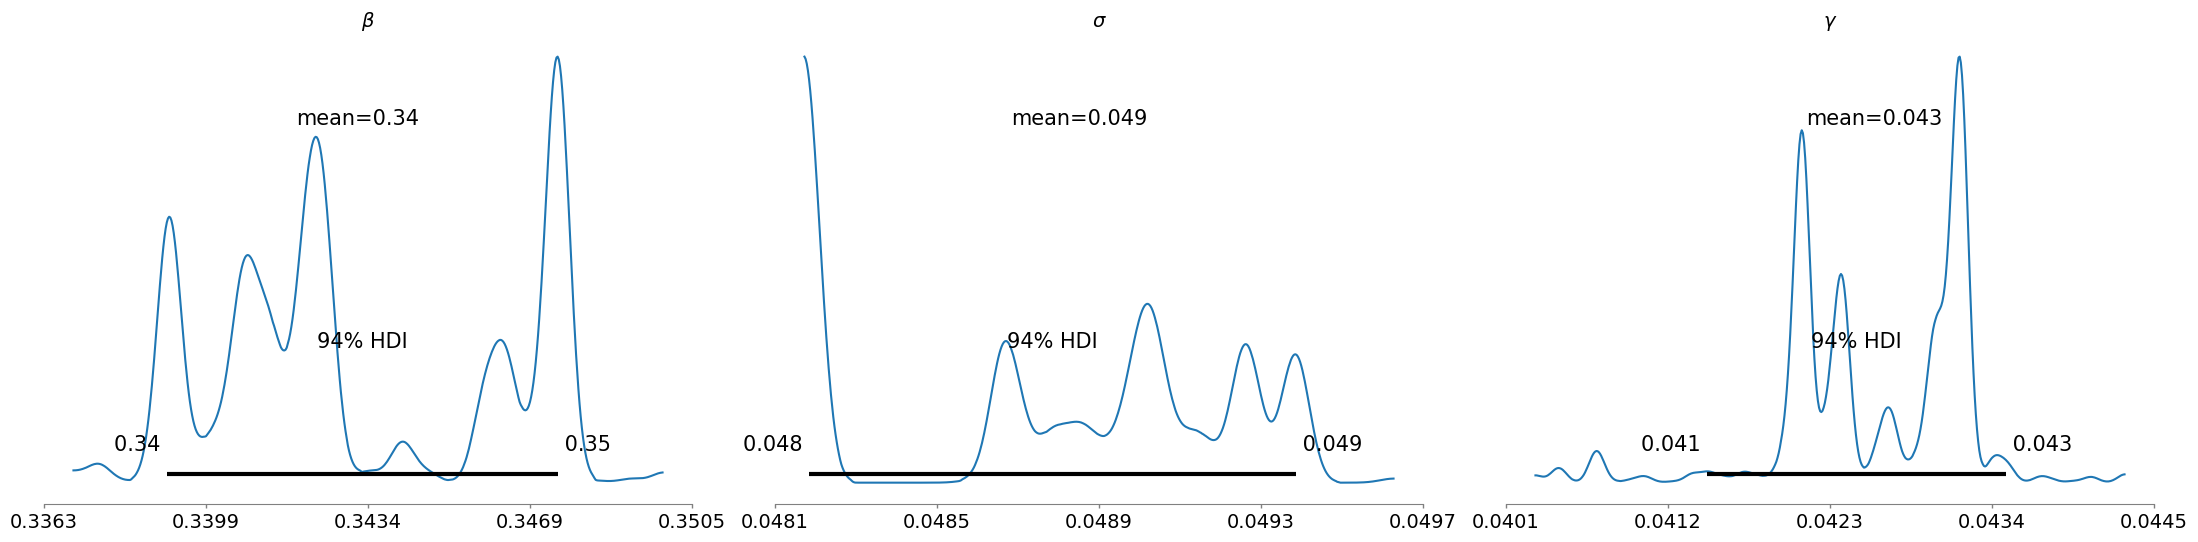

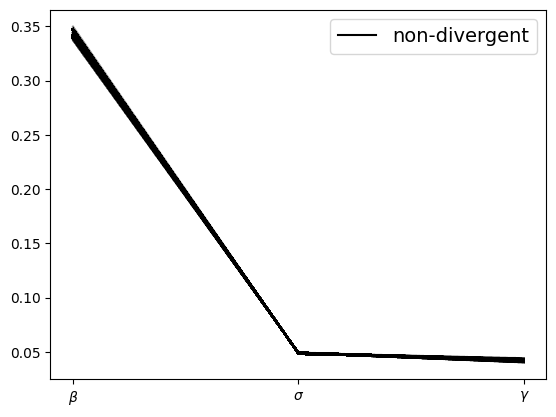

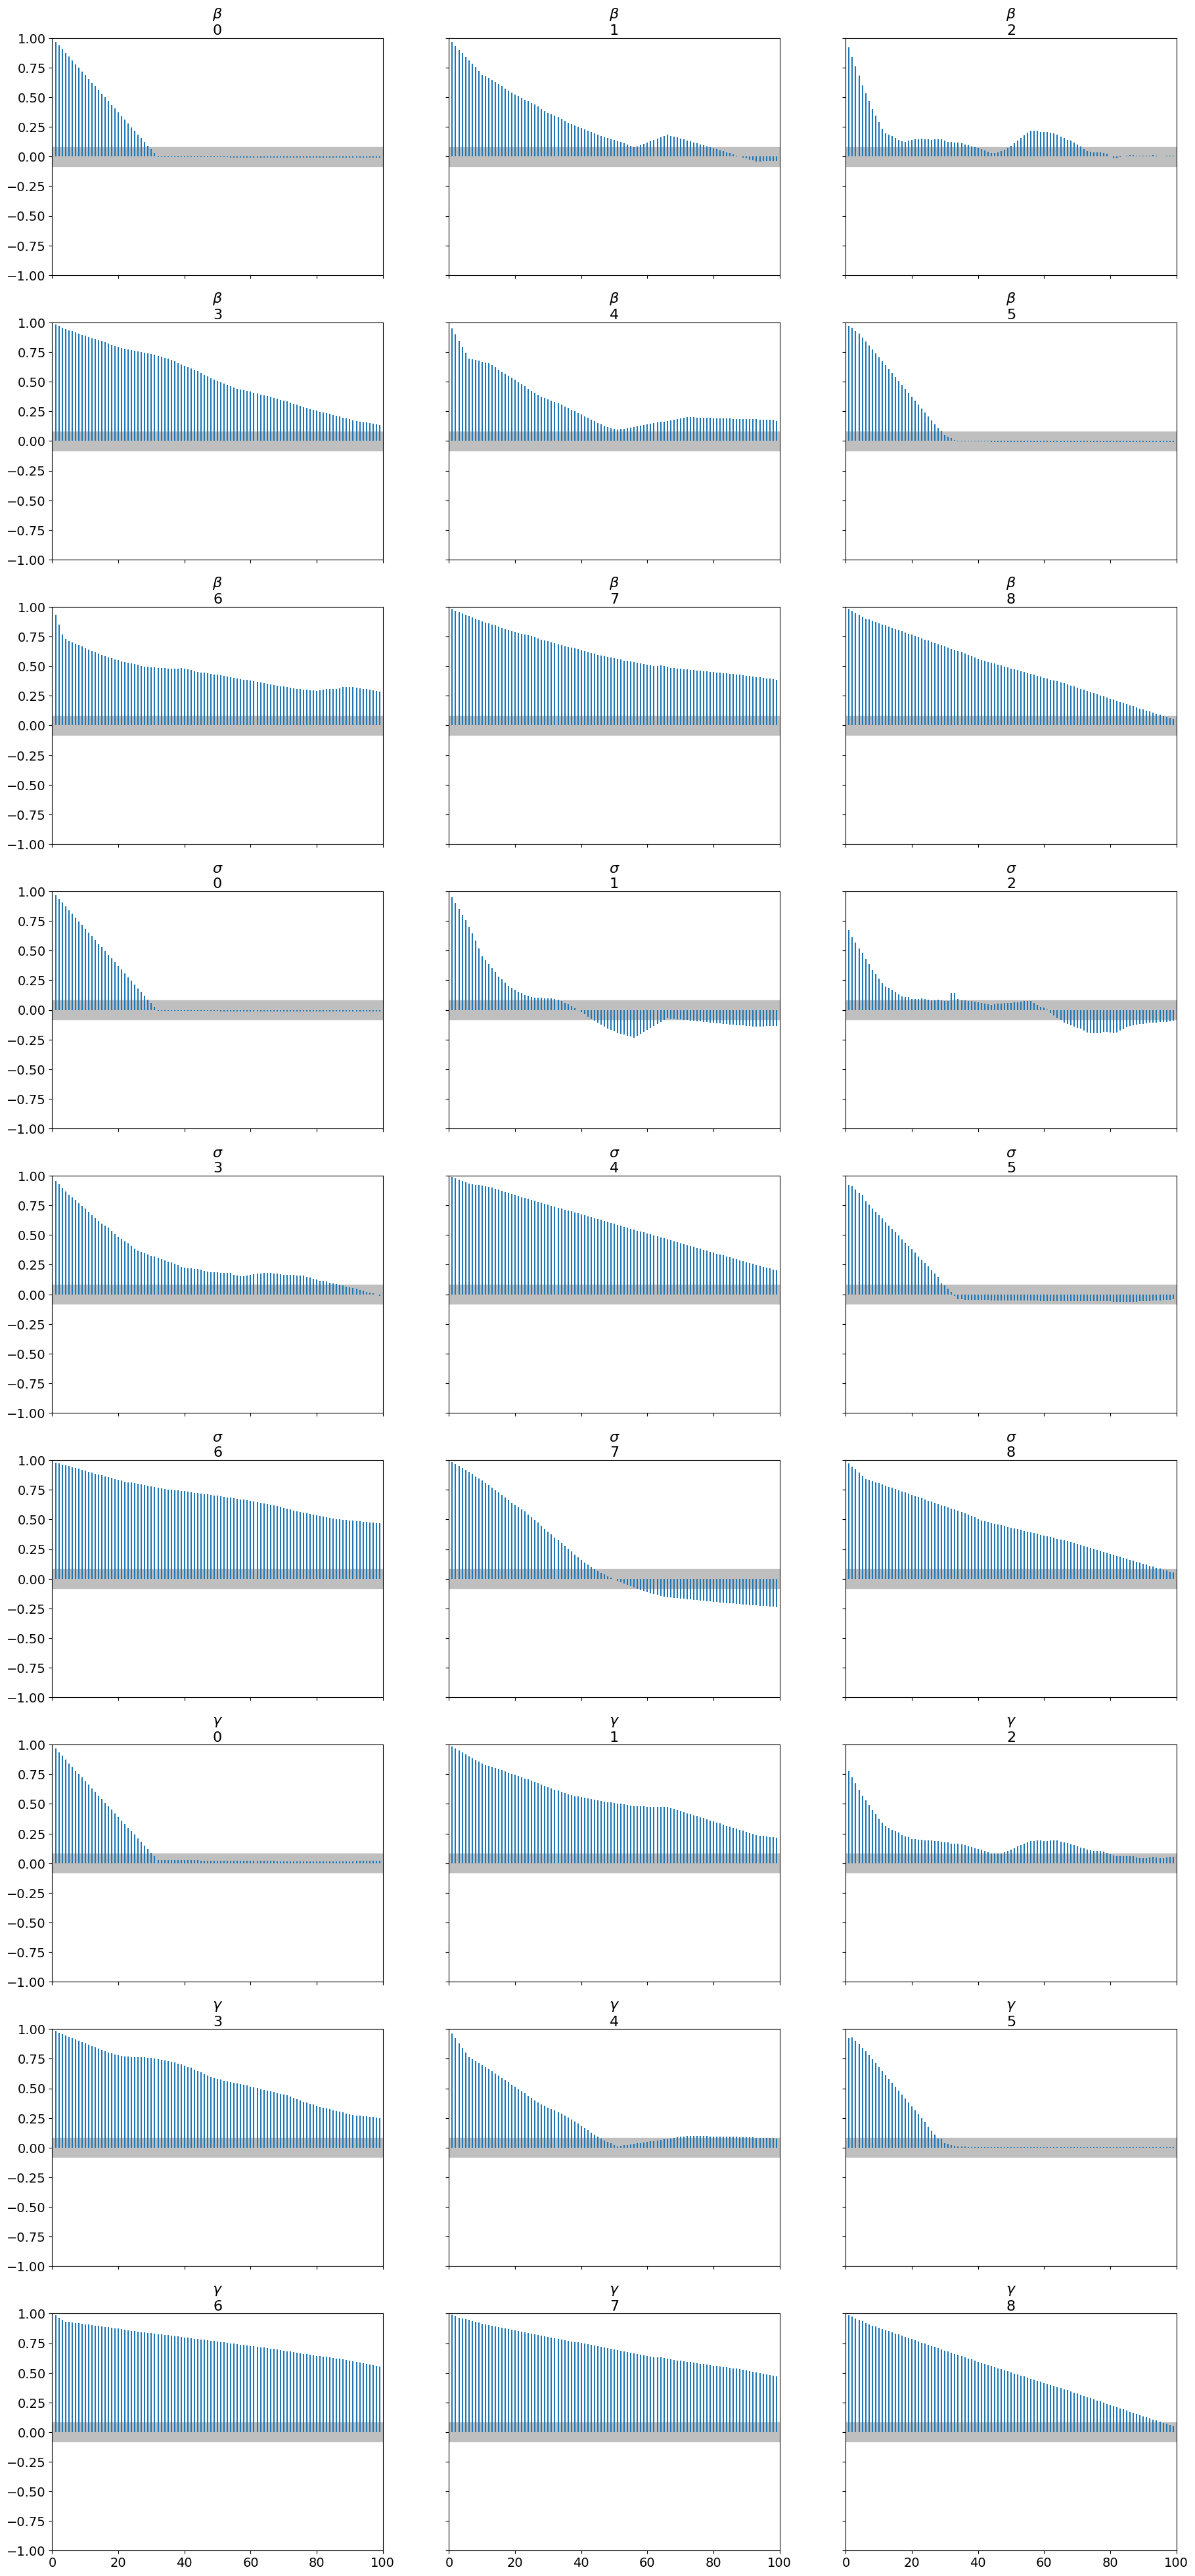

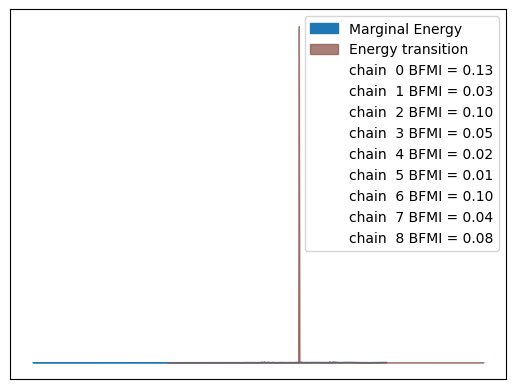

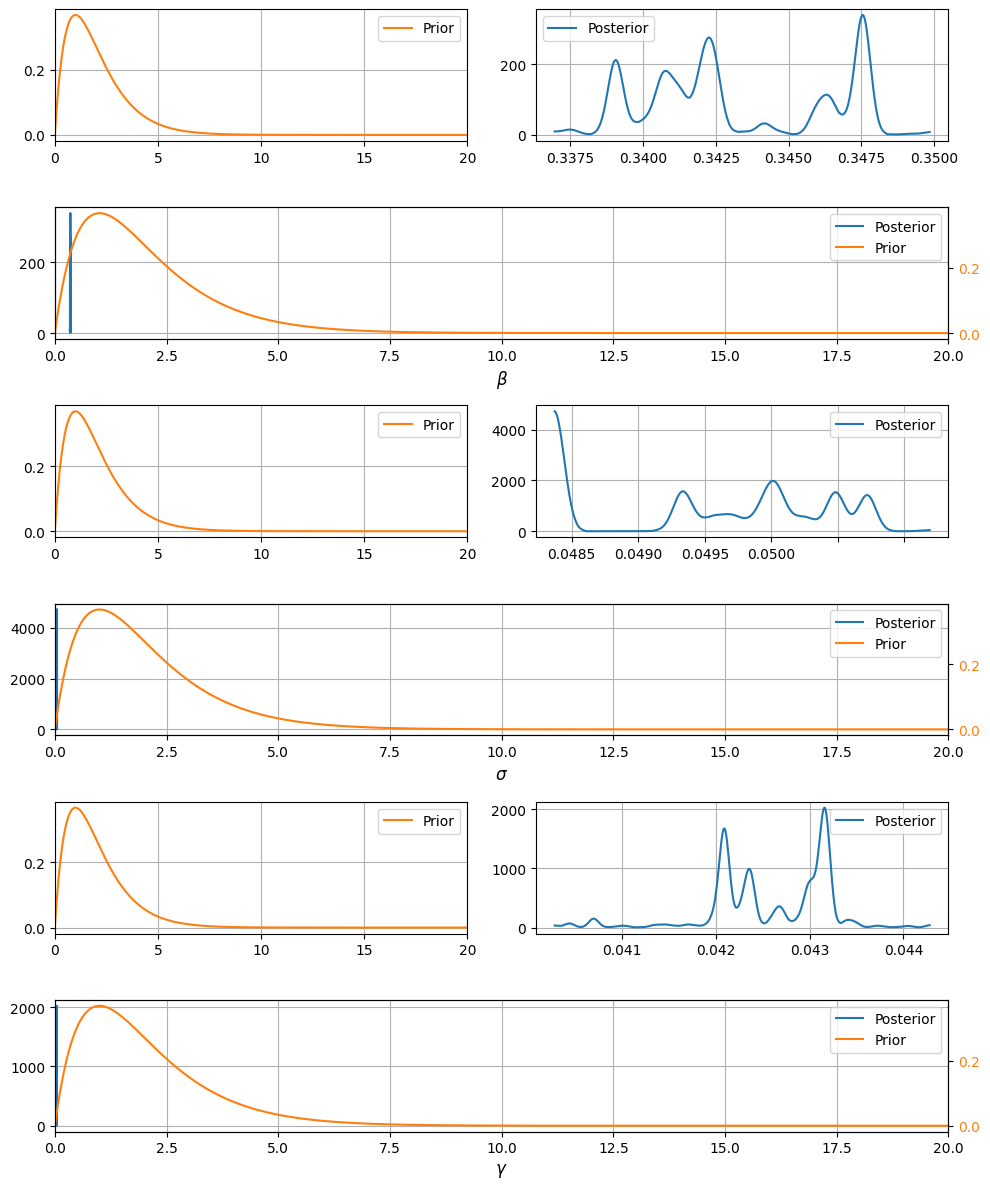

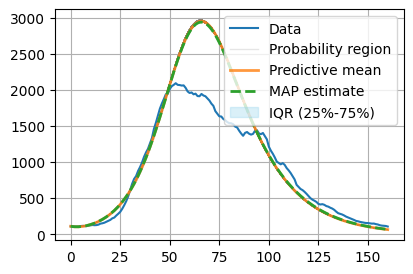

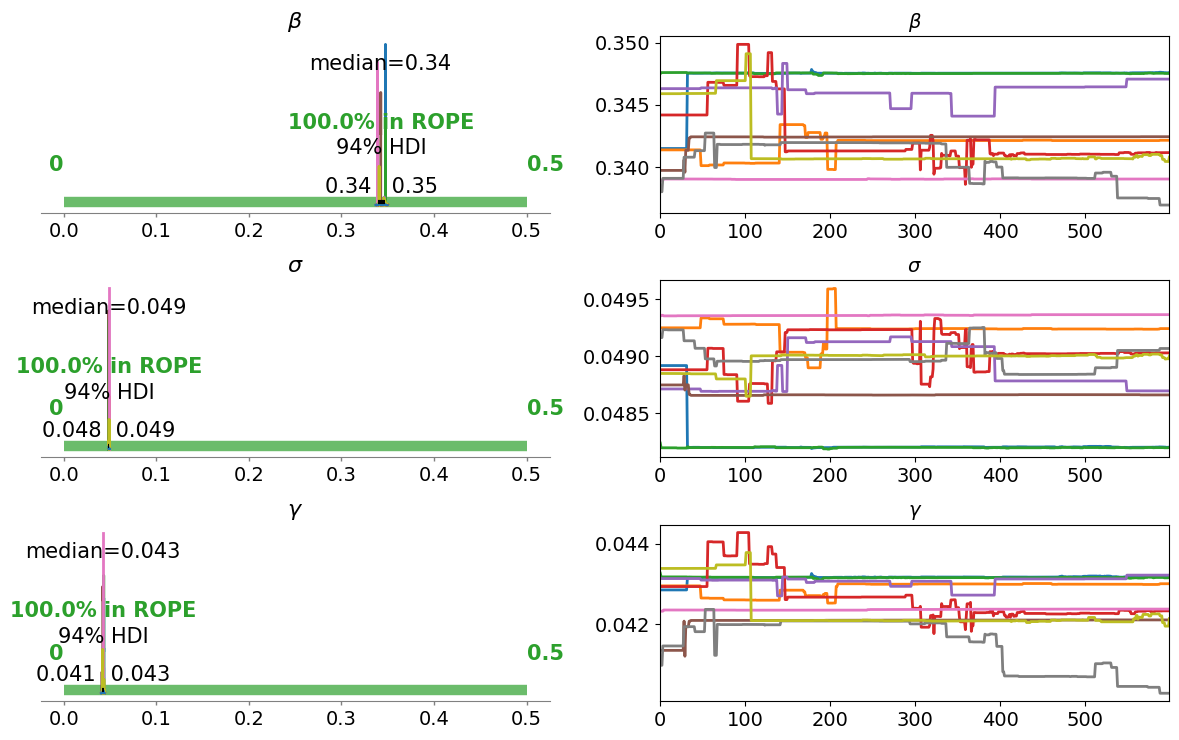

In [15]:
# subsampling and removing burnin
seir_emcee.create_dictionary(burnin=1000, subsample=15)

seir_emcee.report_results()